# Section 5: Advanced Modeling
## 5.1 Imports and Reproducibility Setup
Import modeling, visualization, preprocessing, PCA, and train/test split tools, then set the shared random state.

**Output.** Defines dependencies and `RANDOM_STATE`.


In [1]:
from pathlib import Path
Path("plots_overleaf").mkdir(exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 5.2 Load Cleaned Data
Load the cleaned merged Airbnb dataset generated in Section 1.

**Output.** Shows a preview of the modeling dataset.


In [2]:
# Load data.
df = pd.read_csv("merged_data.csv")
df.head()


,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,satisfaction_rating,bedrooms,dist,metro_dist,attr_index,rest_index,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,98.253896,Amsterdam,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,837.280757,Amsterdam,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,95.386955,Amsterdam,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,875.033098,Amsterdam,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,815.305740,Amsterdam,1


## 5.3 Original Feature Correlations
Inspect linear correlations among log price and the core numeric predictors before fitting flexible models.

**Output.** Saves the original-feature correlation heatmap.


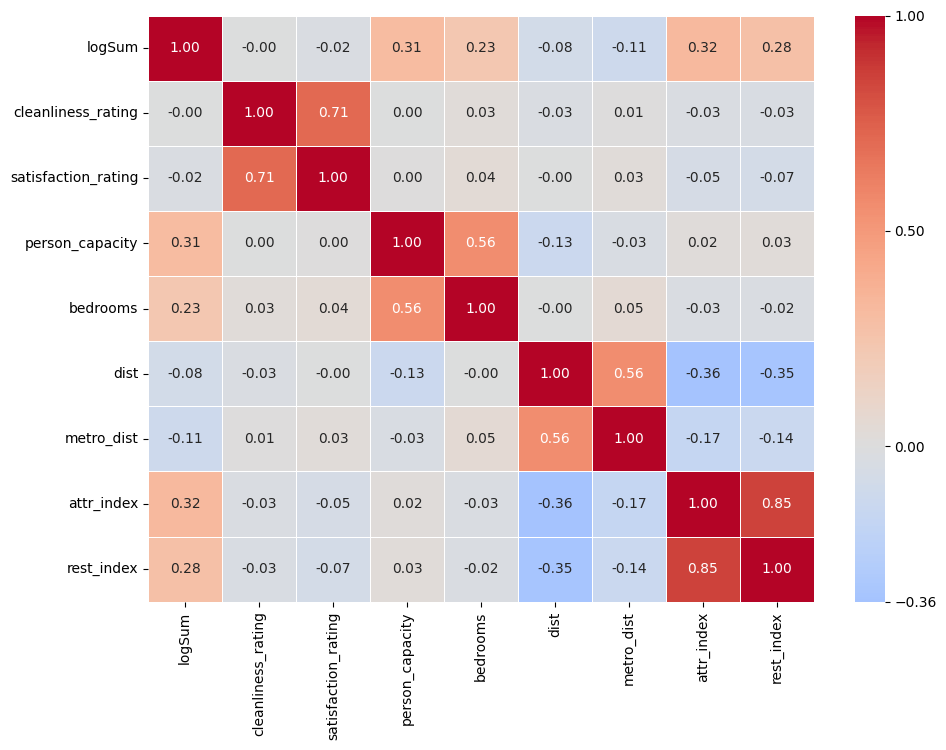

In [3]:
# Plot original-feature correlations.
numeric_cols = [
    "logSum",
    "cleanliness_rating",
    "satisfaction_rating",
    "person_capacity",
    "bedrooms",
    "dist",
    "metro_dist",
    "attr_index",
    "rest_index",
]

corr_matrix_orig = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix_orig,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"ticks": [1.0, 0.5, 0.0, -0.36]},
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("plots_overleaf/3_3_NumericalFeatureCorrelationMatrix.png", dpi=300, bbox_inches="tight")
plt.show()


## 5.4 PCA on Continuous Predictors
Apply PCA to the continuous predictors to identify major feature groups, especially location/access and rating-quality structure.

**Output.** Displays explained variance ratios and component loadings.


In [4]:
# Run PCA on continuous predictors.
all_numeric_cols = [
    "person_capacity",
    "cleanliness_rating",
    "satisfaction_rating",
    "bedrooms",
    "dist",
    "metro_dist",
    "attr_index",
    "rest_index",
]

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(df[all_numeric_cols])

pca_full = PCA(n_components=len(all_numeric_cols), random_state=RANDOM_STATE)
pc_full = pca_full.fit_transform(X_full_scaled)

print("Explained variance ratio per component:")
cumulative = 0.0
for i, evr in enumerate(pca_full.explained_variance_ratio_, 1):
    cumulative += evr
    print(f"  PC{i:02d}: {evr:.3f}  (cumulative: {cumulative:.3f})")

print("\nLoadings (rows = features, cols = PCs):")
loading_df = pd.DataFrame(
    pca_full.components_.T,
    index=all_numeric_cols,
    columns=[f"PC{i}" for i in range(1, len(all_numeric_cols) + 1)],
)
print(loading_df.round(3).to_string())


Explained variance ratio per component:
  PC01: 0.283  (cumulative: 0.283)
  PC02: 0.215  (cumulative: 0.498)
  PC03: 0.193  (cumulative: 0.692)
  PC04: 0.150  (cumulative: 0.841)
  PC05: 0.056  (cumulative: 0.897)
  PC06: 0.049  (cumulative: 0.946)
  PC07: 0.036  (cumulative: 0.982)
  PC08: 0.018  (cumulative: 1.000)

Loadings (rows = features, cols = PCs):
                       PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
person_capacity      0.077  0.192  0.676  0.009 -0.614  0.349  0.013  0.015
cleanliness_rating  -0.080  0.670 -0.207  0.053 -0.020  0.039 -0.705  0.024
satisfaction_rating -0.108  0.667 -0.195  0.053  0.009  0.023  0.707 -0.034
bedrooms            -0.006  0.210  0.670  0.109  0.651 -0.267 -0.022 -0.006
dist                -0.473 -0.139 -0.022  0.444  0.274  0.695 -0.007 -0.001
metro_dist          -0.349 -0.073  0.023  0.674 -0.342 -0.548 -0.005  0.027
attr_index           0.564  0.024 -0.084  0.394  0.071  0.109  0.041  0.707
rest_index           0.558  0.0

## 5.5 PCA Price Projection
Plot listings in the first two principal-component dimensions and color them by log price.

**Output.** Saves the PCA scatter plot.


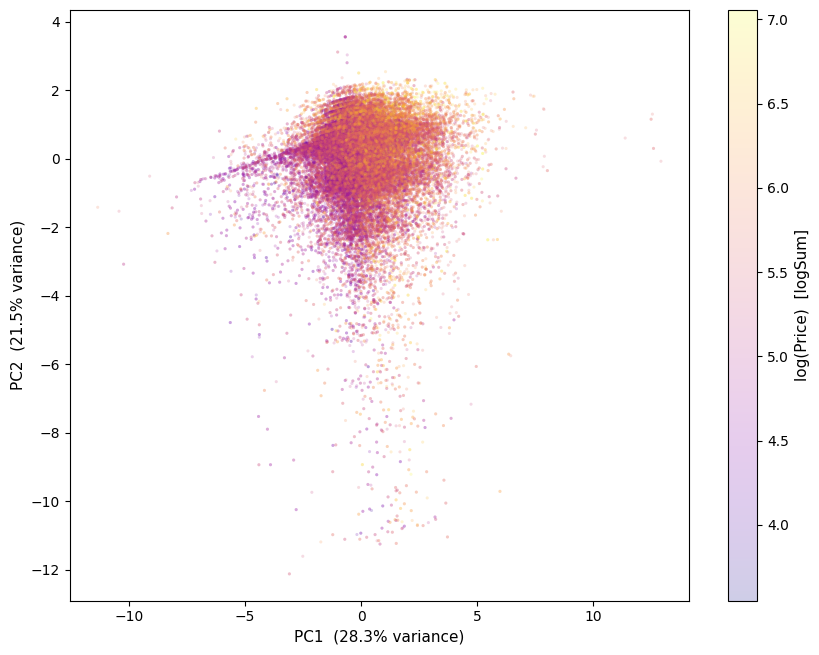

In [5]:
# Plot listings in the first two PCA dimensions.
fig, ax = plt.subplots(figsize=(9, 7))

sc_full = ax.scatter(
    pc_full[:, 0],
    pc_full[:, 1],
    c=df["logSum"],
    cmap="plasma",
    alpha=0.2,
    s=5,
    linewidths=0,
)

cbar = fig.colorbar(sc_full, ax=ax)
cbar.set_label("log(Price)  [logSum]", fontsize=11)

ax.set_xlabel(f"PC1  ({pca_full.explained_variance_ratio_[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({pca_full.explained_variance_ratio_[1]:.1%} variance)", fontsize=11)

plt.tight_layout(rect=[0, 0, 0.96, 0.95])
plt.savefig("plots_overleaf/App4_0_FullFeaturePCScatterLogPrice.png", dpi=300, bbox_inches="tight")
plt.show()


## 5.6 Feature Processing and Train/Test Split
Standardize numeric predictors, pass through binary predictors, encode city fixed effects, and create a city-stratified 80/20 split.

**Output.** Creates processed train/test matrices and targets for XGBoost.


In [6]:
# Define predictors and preprocessing.
numeric_cols = [
    "cleanliness_rating",
    "satisfaction_rating",
    "person_capacity",
    "bedrooms",
    "dist",
    "metro_dist",
    "attr_index",
    "rest_index",
]

binary_cols = [
    "room_type_apt",
    "room_type_private",
    "is_superhost",
    "multi",
    "biz",
    "is_weekday",
]

categorical_cols = ["city"]
target_col = "logSum"
raw_feature_cols = numeric_cols + binary_cols + categorical_cols

preprocess = ColumnTransformer(
    transformers=[
        ("scale_numeric", StandardScaler(), numeric_cols),
        ("binary", "passthrough", binary_cols),
        (
            "city_dummies",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            categorical_cols,
        ),
    ],
    remainder="drop",
)

X = df[raw_feature_cols].copy()
y = df[target_col].copy()
X_processed = preprocess.fit_transform(X)

# Create stratified train/test split.
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["city"],
)


## 5.7 Baseline XGBoost Fit
Fit a baseline XGBoost regressor using a fixed set of reasonable hyperparameters.

**Output.** Creates baseline XGBoost predictions on the test set.


In [7]:
# Fit baseline XGBoost model.
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)


## 5.8 Baseline XGBoost Evaluation
Evaluate the baseline XGBoost model on held-out listings.

**Output.** Displays test MSE and test R².


In [8]:
# Evaluate baseline XGBoost model.
from sklearn.metrics import root_mean_squared_error, r2_score

rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R^2: {r2:.4f}")

Test RMSE: 0.2536
Test R^2: 0.7968


## 5.9 Transformed Feature Names
Recover readable feature names after scaling, binary passthrough, and city dummy encoding.

**Output.** Creates `feature_names` for importance and SHAP plots.


In [9]:
# Recover transformed feature names.
city_dummy_names = list(
    preprocess.named_transformers_["city_dummies"].get_feature_names_out(categorical_cols)
)
feature_names = numeric_cols + binary_cols + city_dummy_names


## 5.10 Baseline Native Feature Importance
Use XGBoost gain-based native importance to summarize which features the baseline tree ensemble uses most.

**Output.** Saves the baseline native feature-importance plot.


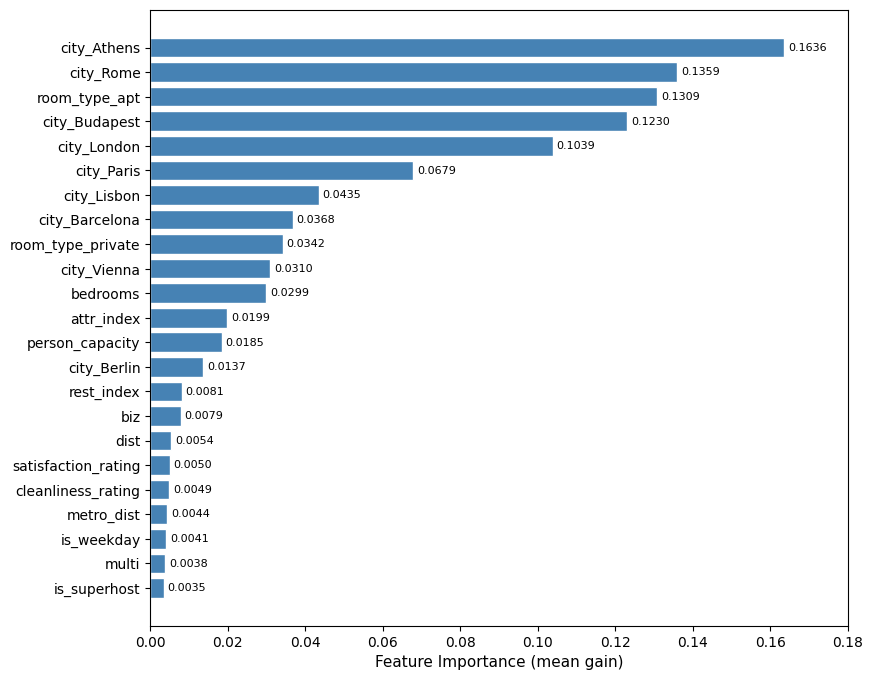

In [10]:
# Plot baseline XGBoost native feature importance.
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": model.feature_importances_})
    .sort_values("importance", ascending=True)
)

plt.close("all")
fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(
    importance_df["feature"],
    importance_df["importance"],
    color="steelblue",
    edgecolor="white",
)
ax.set_xlim(0, 0.18)
ax.set_xlabel("Feature Importance (mean gain)", fontsize=11)
ax.axvline(0, color="black", linewidth=0.6)
for bar, val in zip(bars, importance_df["importance"]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        ha="left",
        fontsize=8,
    )
plt.savefig("plots_overleaf/6_1_BaselineNativeFeatureImportance.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


## 5.11 Baseline SHAP Values
Compute SHAP values for the baseline XGBoost model to decompose predictions into feature-level contributions.

**Output.** Creates baseline SHAP values for the test set.


In [11]:
# Compute baseline SHAP values.
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)


## 5.12 Baseline SHAP Distribution
Visualize the distribution of baseline SHAP contributions across listings.

**Output.** Saves the baseline SHAP violin plot.


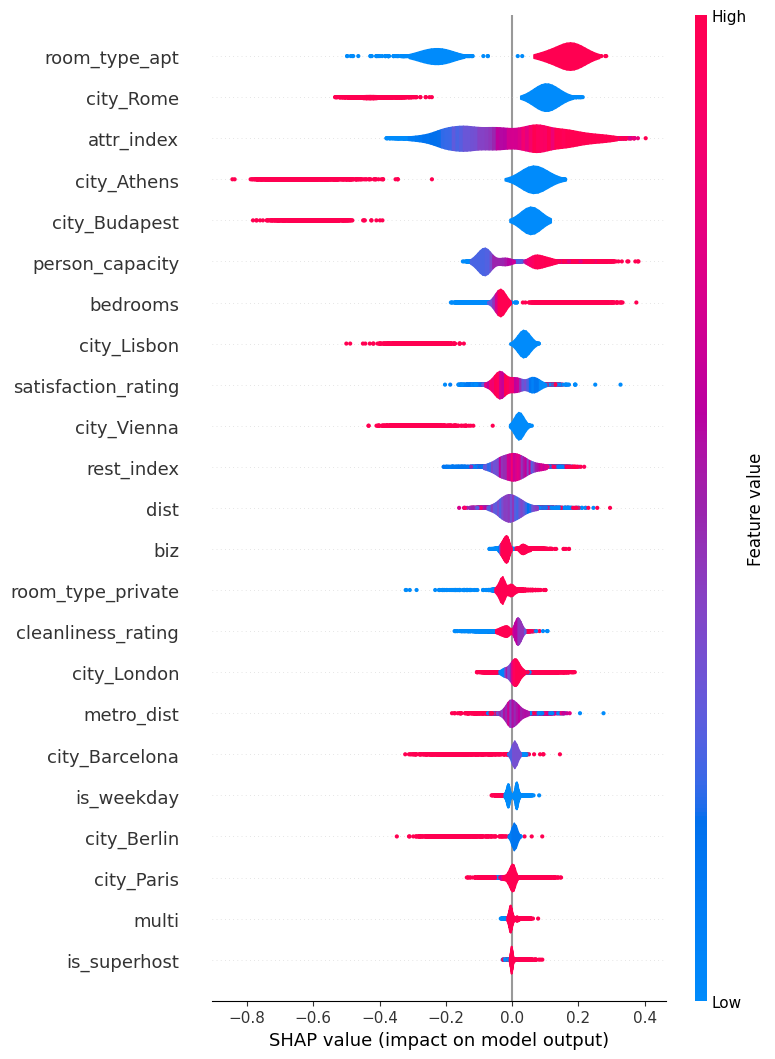

In [12]:
# Plot baseline SHAP value distribution.
plt.close("all")
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="violin",
    show=False,
    rng=np.random.default_rng(RANDOM_STATE),
    max_display=len(feature_names),
)
fig = plt.gcf()
plt.savefig("plots_overleaf/6_1_BaselineSHAPViolin.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


## 5.13 XGBoost Hyperparameter Search
Tune XGBoost hyperparameters with Optuna using cross-validated RMSE on the training set.

**Output.** Displays the best CV-RMSE and selected hyperparameters.


In [13]:
# Tune XGBoost hyperparameters with Optuna.
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }
    xgb = XGBRegressor(**params)
    scores = cross_val_score(
        xgb,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_squared_error",
    )
    return float(np.sqrt(-scores.mean()))

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=50)

print(f"\nBest CV-RMSE : {study.best_value:.4f}")
print("Best params  :")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")



Best CV-RMSE : 0.2245
Best params  :
  n_estimators        : 1635
  max_depth           : 9
  learning_rate       : 0.050293638326551766
  subsample           : 0.6845180920487626
  colsample_bytree    : 0.6134923868822042
  min_child_weight    : 2
  reg_alpha           : 0.012190852593602126
  reg_lambda          : 3.579678652466424e-06


## 5.14 Tuned XGBoost Evaluation
Refit XGBoost with the selected hyperparameters and compare test performance with the baseline model.

**Output.** Displays the baseline and tuned XGBoost test metrics.


In [14]:
# Fit and evaluate tuned XGBoost model.
model_tuned = XGBRegressor(**study.best_params, random_state=RANDOM_STATE, n_jobs=-1)
model_tuned.fit(X_train, y_train)

pred_tuned = model_tuned.predict(X_test)
rmse_tuned = root_mean_squared_error(y_test, pred_tuned)
r2_tuned = r2_score(y_test, pred_tuned)

print(f"{'Model':<22} {'Test RMSE':>10}  {'Test R²':>8}")
print("-" * 44)
print(f"{'Baseline XGBoost':<22} {rmse:>10.4f}  {r2:>8.4f}")
print(f"{'Tuned XGBoost':<22} {rmse_tuned:>10.4f}  {r2_tuned:>8.4f}")


Model                   Test RMSE   Test R²
--------------------------------------------
Baseline XGBoost           0.2536    0.7968
Tuned XGBoost              0.2015    0.8717


## 5.15 Tuned Native Feature Importance
Plot native gain-based feature importance for the tuned XGBoost model.

**Output.** Saves the tuned native feature-importance plot.


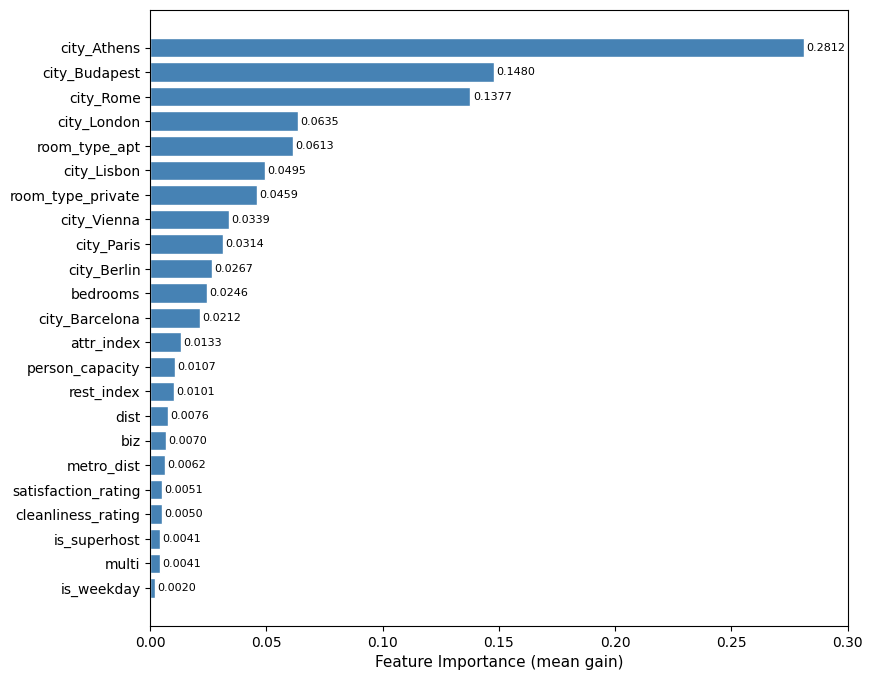

In [15]:
# Plot tuned XGBoost native feature importance.
importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": model_tuned.feature_importances_})
    .sort_values("importance", ascending=True)
)

plt.close("all")
fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(
    importance_df["feature"],
    importance_df["importance"],
    color="steelblue",
    edgecolor="white",
)
ax.set_xlim(0, 0.30)
ax.set_xlabel("Feature Importance (mean gain)", fontsize=11)
ax.axvline(0, color="black", linewidth=0.6)
for bar, val in zip(bars, importance_df["importance"]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        ha="left",
        fontsize=8,
    )
plt.savefig("plots_overleaf/6_1_TunedNativeFeatureImportance.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


## 5.16 Tuned SHAP Distribution
Compute and visualize SHAP values for the tuned XGBoost model.

**Output.** Saves the tuned SHAP violin plot.


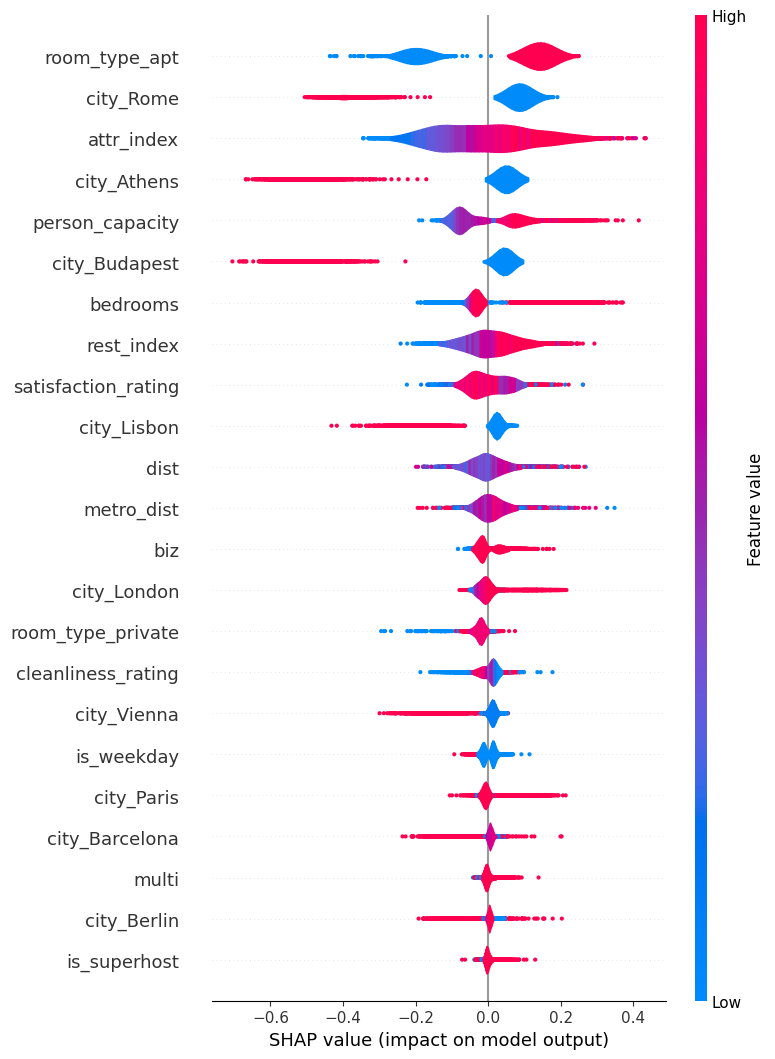

In [16]:
# Compute and plot tuned SHAP values.
tuned_explainer = shap.TreeExplainer(model_tuned)
tuned_shap_values = tuned_explainer.shap_values(X_test)

city_dummy_names = list(
    preprocess.named_transformers_["city_dummies"].get_feature_names_out(categorical_cols)
)
feature_names = numeric_cols + binary_cols + city_dummy_names

plt.close("all")
shap.summary_plot(
    tuned_shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="violin",
    show=False,
    rng=np.random.default_rng(RANDOM_STATE),
    max_display=len(feature_names),
)
fig = plt.gcf()
plt.savefig("plots_overleaf/6_1_TunedSHAPViolin.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


## 5.17 Tuned SHAP Global Importance
Rank tuned-model features by mean absolute SHAP contribution.

**Output.** Saves the tuned SHAP global-importance bar plot.


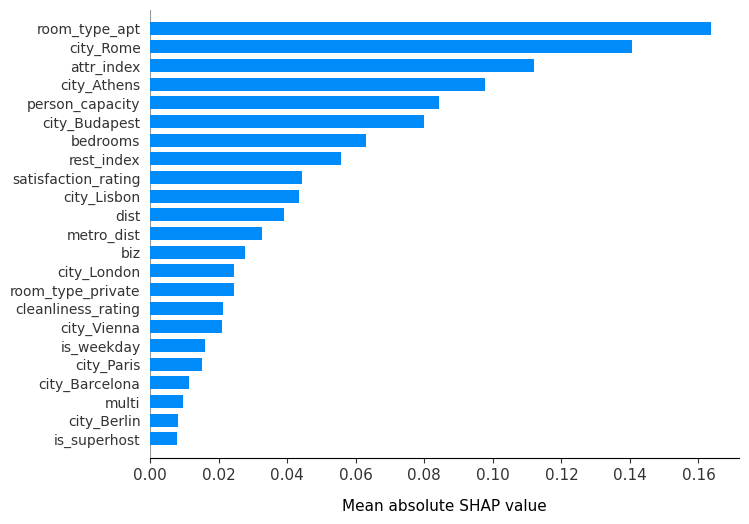

In [17]:
# Plot tuned SHAP global importance.
plt.close("all")
shap.summary_plot(
    tuned_shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
    rng=np.random.default_rng(RANDOM_STATE),
    max_display=len(feature_names),
)
fig = plt.gcf()
fig.set_size_inches(9.2, 6.4)
ax = fig.axes[0]
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel("Mean absolute SHAP value", fontsize=11, labelpad=12)
fig.subplots_adjust(left=0.34, right=0.98, bottom=0.18, top=0.88)
plt.savefig("plots_overleaf/6_1_TunedSHAPBarImportance.png", bbox_inches="tight", pad_inches=0.18, dpi=300)
plt.show()
plt.close(fig)


## 5.18 Mutual SHAP Dependence Plots
Plot selected feature pairs in both directions to inspect interactions suggested by the tuned XGBoost model.

**Output.** Saves ordered mutual SHAP dependence plots.


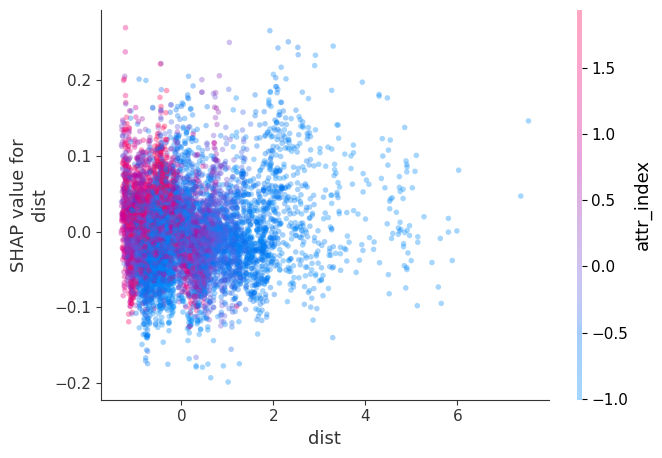

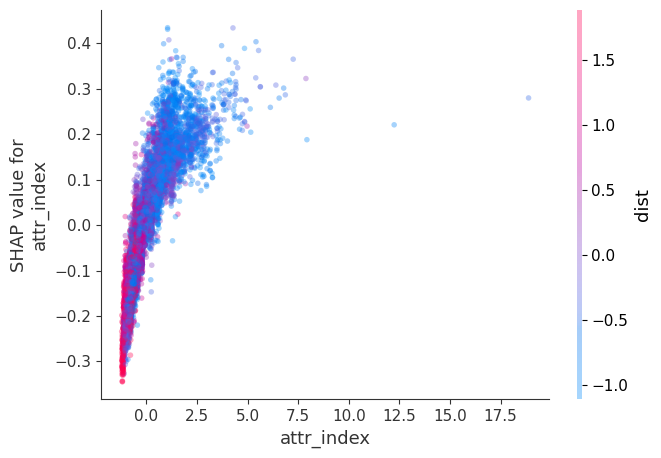

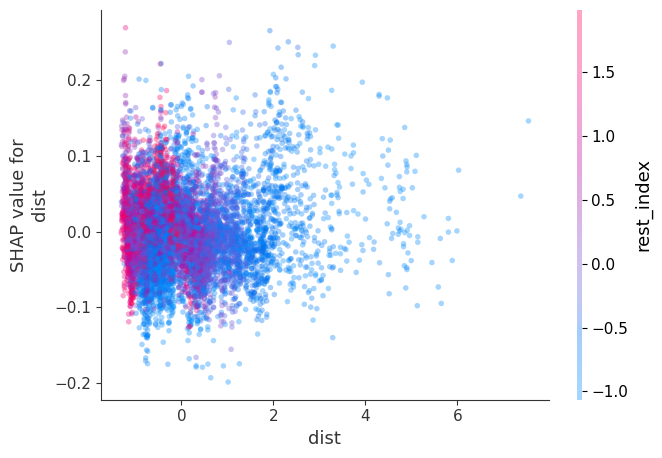

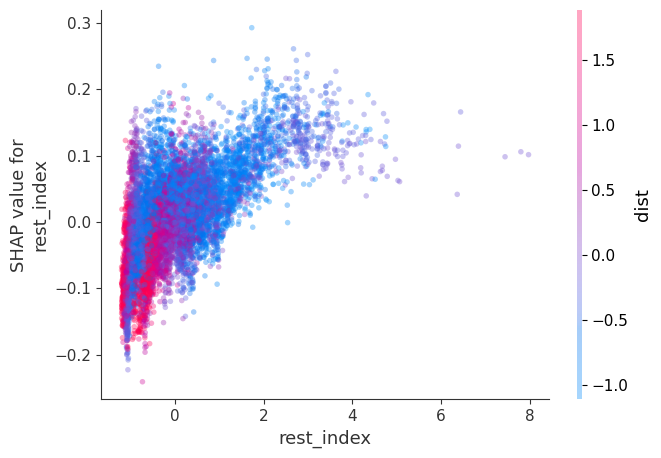

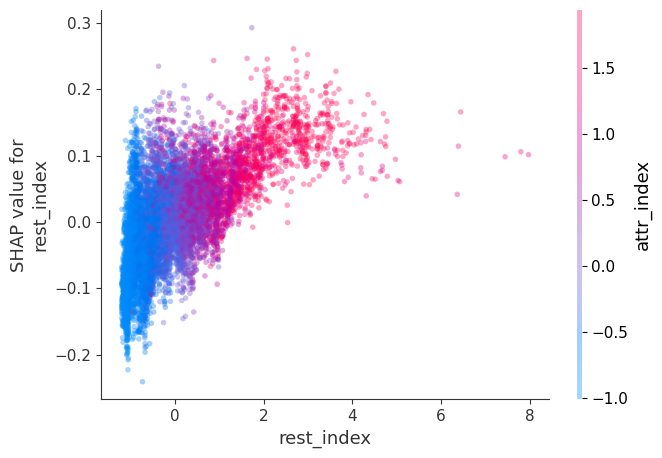

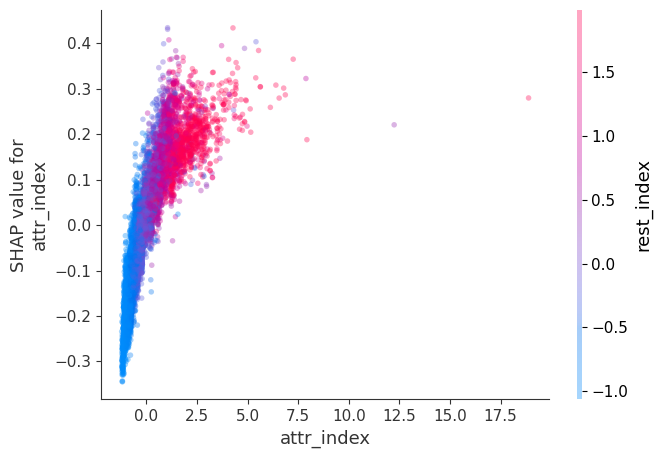

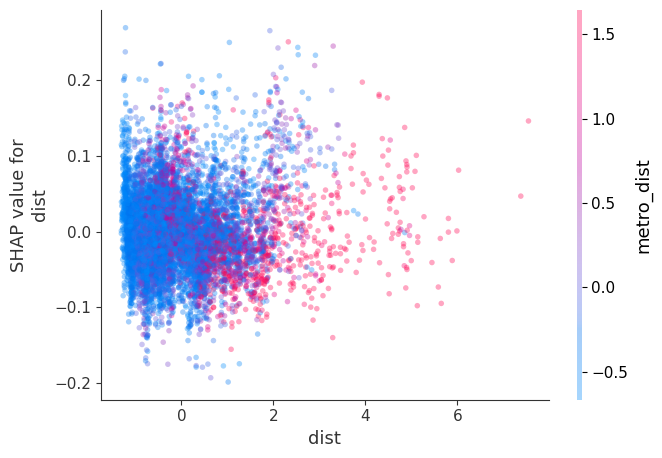

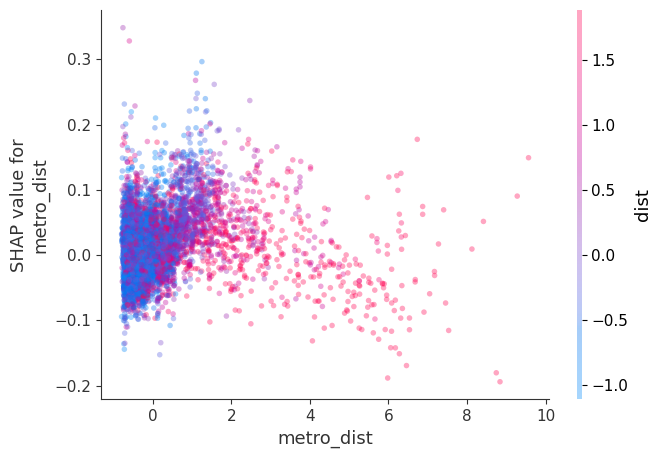

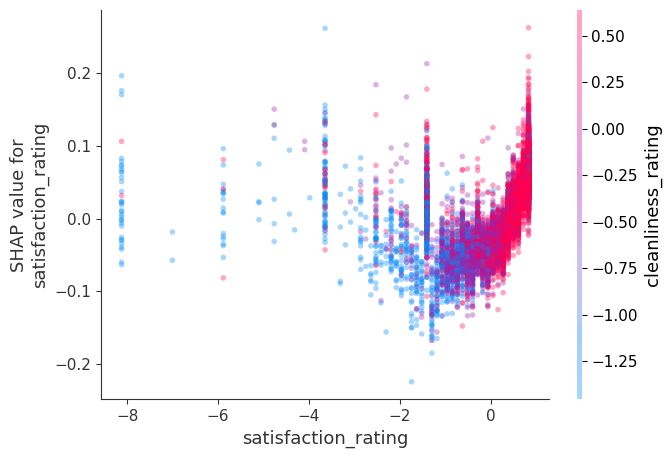

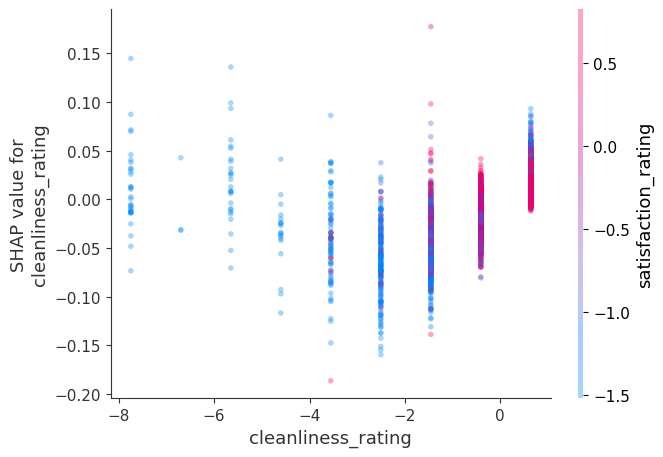

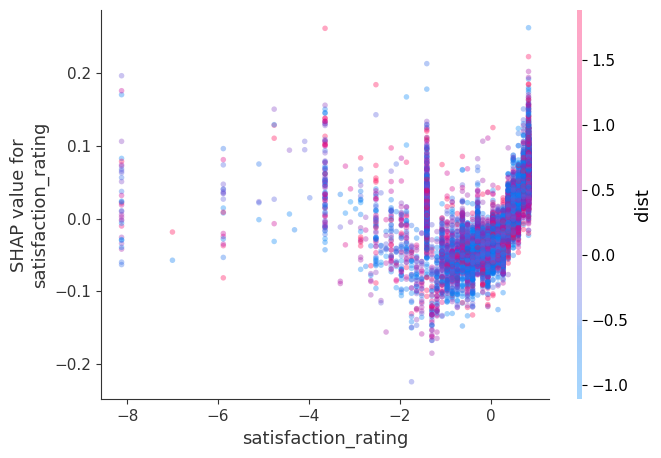

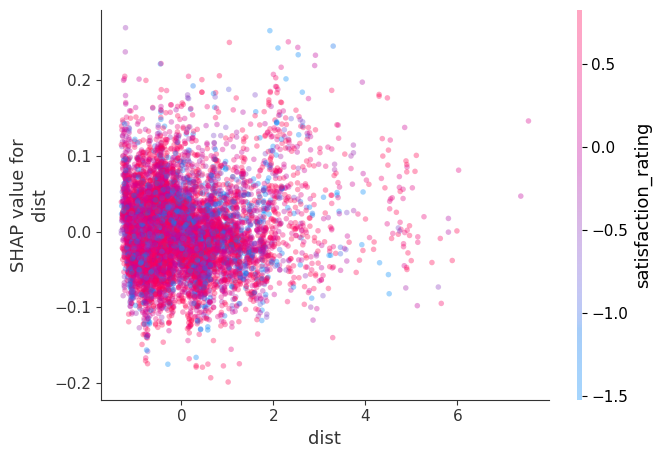

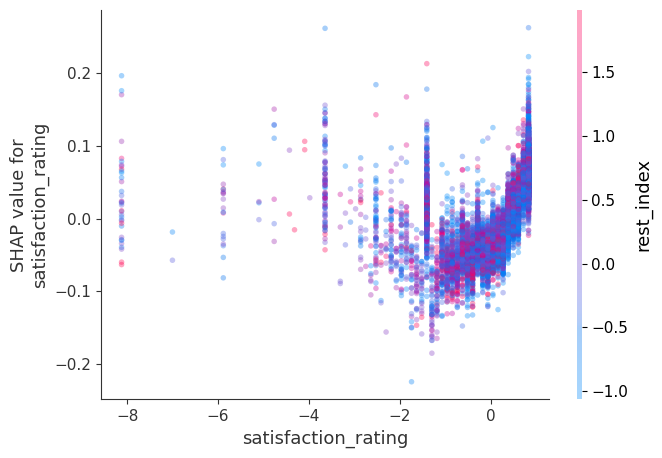

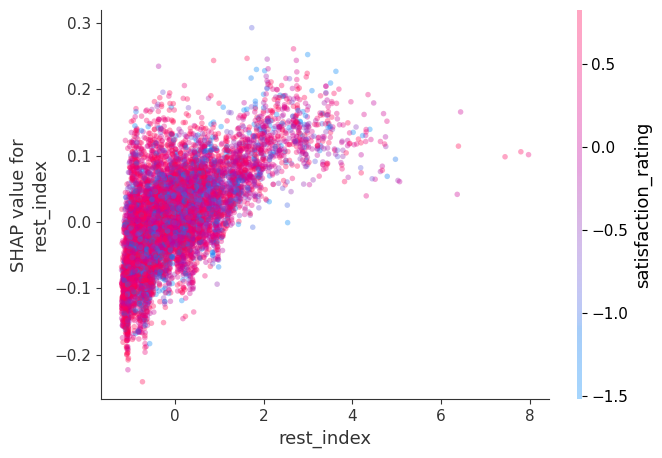

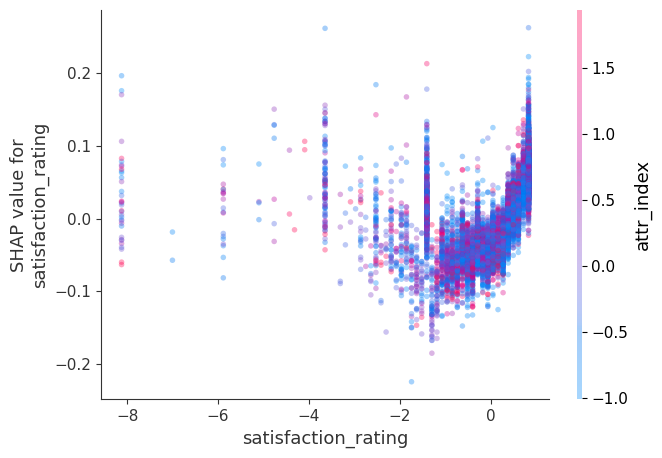

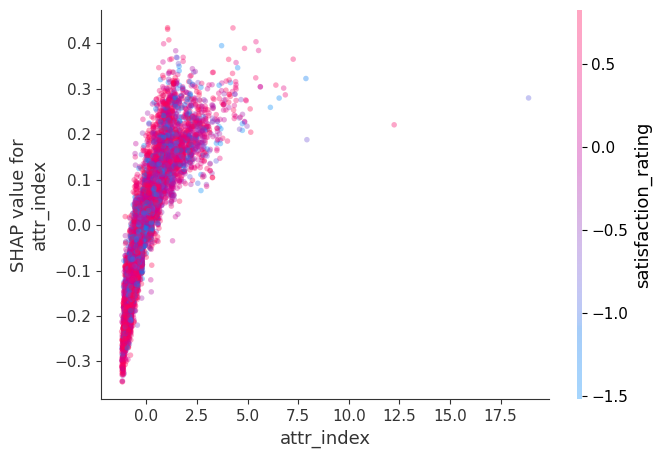

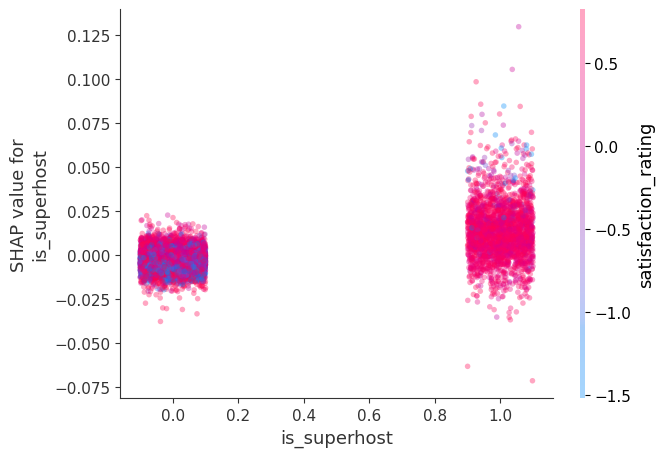

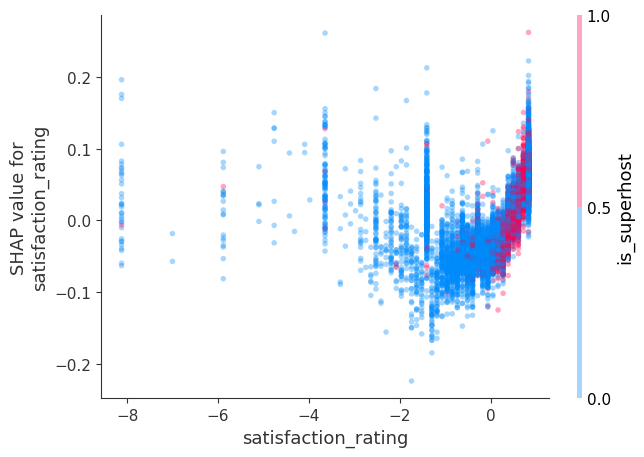

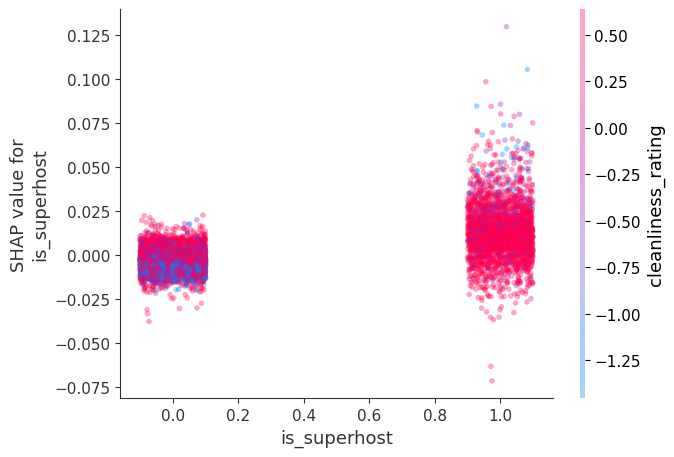

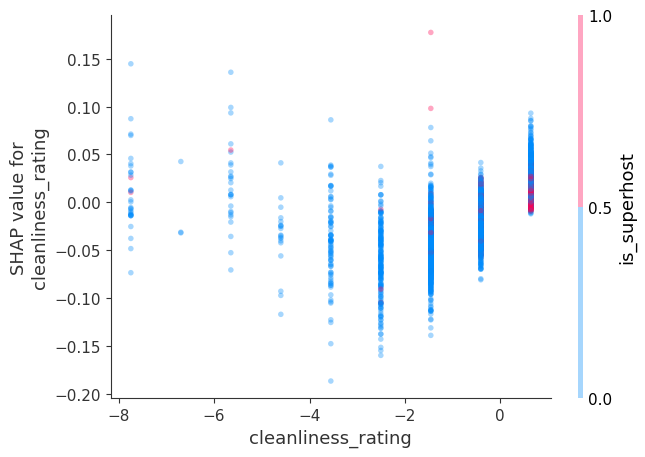

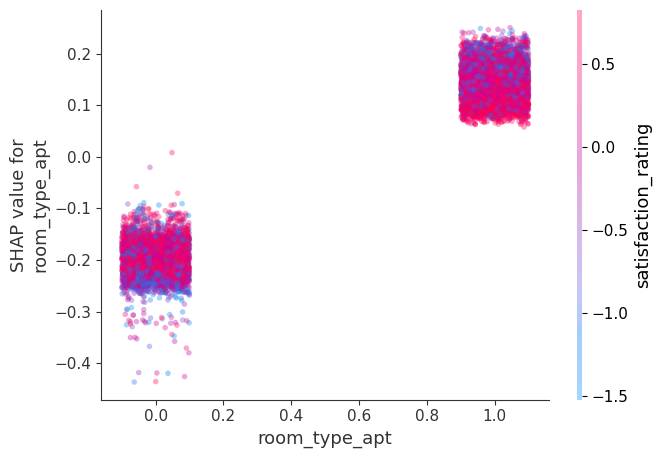

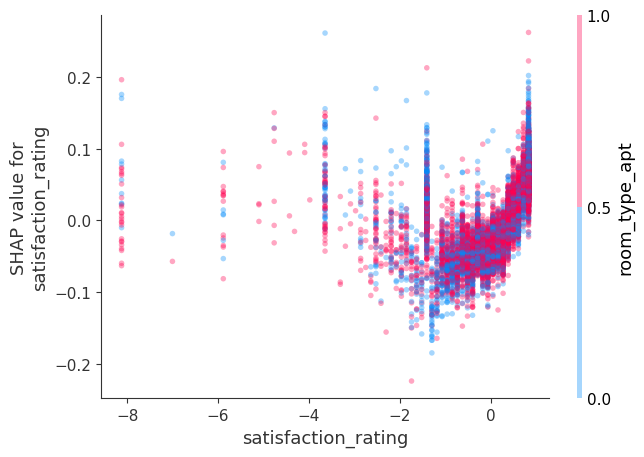

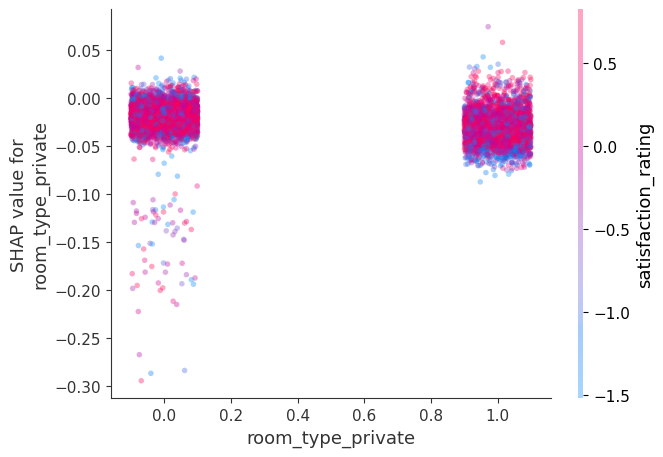

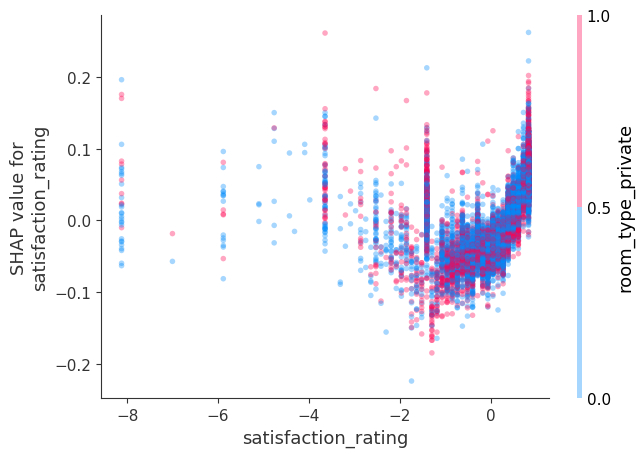

In [18]:
# Plot mutual SHAP dependence pairs.
ordered_mutual_pairs = [
    ("dist", "attr_index"),
    ("dist", "rest_index"),
    ("rest_index", "attr_index"),
    ("dist", "metro_dist"),
    ("satisfaction_rating", "cleanliness_rating"),
    ("satisfaction_rating", "dist"),
    ("satisfaction_rating", "rest_index"),
    ("satisfaction_rating", "attr_index"),
    ("is_superhost", "satisfaction_rating"),
    ("is_superhost", "cleanliness_rating"),
    ("room_type_apt", "satisfaction_rating"),
    ("room_type_private", "satisfaction_rating"),
]

feature_title_map = {
    "dist": "City-Center Distance",
    "attr_index": "Attraction Access Index",
    "rest_index": "Restaurant Access Index",
    "metro_dist": "Metro Distance",
    "satisfaction_rating": "Guest Satisfaction",
    "cleanliness_rating": "Cleanliness Rating",
    "is_superhost": "Superhost Indicator",
    "room_type_apt": "Entire-Apartment Indicator",
    "room_type_private": "Private-Room Indicator",
}

feature_file_map = {
    "dist": "dist",
    "attr_index": "attrIndex",
    "rest_index": "restIndex",
    "metro_dist": "metroDist",
    "satisfaction_rating": "satisfaction",
    "cleanliness_rating": "cleanliness",
    "is_superhost": "superhost",
    "room_type_apt": "roomTypeApt",
    "room_type_private": "roomTypePrivate",
}

binary_features = {"is_superhost", "room_type_apt", "room_type_private"}
feature_name_set = set(feature_names)
missing_features = sorted({feature for pair in ordered_mutual_pairs for feature in pair} - feature_name_set)
if missing_features:
    raise ValueError(f"Missing features for SHAP dependence plots: {missing_features}")

dependence_plot_file_map = {
    ("dist", "attr_index"): "plots_overleaf/6_2_DistanceByAttractionAccess.png",
    ("attr_index", "dist"): "plots_overleaf/6_2_AttractionAccessByDistance.png",
    ("dist", "rest_index"): "plots_overleaf/6_2_DistanceByRestaurantAccess.png",
    ("rest_index", "dist"): "plots_overleaf/6_2_RestaurantAccessByDistance.png",
    ("rest_index", "attr_index"): "plots_overleaf/6_2_RestaurantAccessByAttractionAccess.png",
    ("attr_index", "rest_index"): "plots_overleaf/6_2_AttractionAccessByRestaurantAccess.png",
    ("dist", "metro_dist"): "plots_overleaf/6_2_DistanceByMetroDistance.png",
    ("metro_dist", "dist"): "plots_overleaf/6_2_MetroDistanceByDistance.png",
    ("satisfaction_rating", "cleanliness_rating"): "plots_overleaf/6_2_GuestSatisfactionByCleanliness.png",
    ("cleanliness_rating", "satisfaction_rating"): "plots_overleaf/6_2_CleanlinessByGuestSatisfaction.png",
    ("satisfaction_rating", "dist"): "plots_overleaf/6_2_GuestSatisfactionByDistance.png",
    ("dist", "satisfaction_rating"): "plots_overleaf/6_2_DistanceByGuestSatisfaction.png",
    ("satisfaction_rating", "rest_index"): "plots_overleaf/6_2_GuestSatisfactionByRestaurantAccess.png",
    ("rest_index", "satisfaction_rating"): "plots_overleaf/6_2_RestaurantAccessByGuestSatisfaction.png",
    ("satisfaction_rating", "attr_index"): "plots_overleaf/6_2_GuestSatisfactionByAttractionAccess.png",
    ("attr_index", "satisfaction_rating"): "plots_overleaf/6_2_AttractionAccessByGuestSatisfaction.png",
    ("is_superhost", "satisfaction_rating"): "plots_overleaf/6_2_SuperhostByGuestSatisfaction.png",
    ("satisfaction_rating", "is_superhost"): "plots_overleaf/6_2_GuestSatisfactionBySuperhost.png",
    ("is_superhost", "cleanliness_rating"): "plots_overleaf/6_2_SuperhostByCleanliness.png",
    ("cleanliness_rating", "is_superhost"): "plots_overleaf/6_2_CleanlinessBySuperhost.png",
    ("room_type_apt", "satisfaction_rating"): "plots_overleaf/6_2_EntireApartmentByGuestSatisfaction.png",
    ("satisfaction_rating", "room_type_apt"): "plots_overleaf/6_2_GuestSatisfactionByEntireApartment.png",
    ("room_type_private", "satisfaction_rating"): "plots_overleaf/6_2_PrivateRoomByGuestSatisfaction.png",
    ("satisfaction_rating", "room_type_private"): "plots_overleaf/6_2_GuestSatisfactionByPrivateRoom.png",
}

for first_feature, second_feature in ordered_mutual_pairs:
    for feature, interaction in [(first_feature, second_feature), (second_feature, first_feature)]:
        feature_label = feature_title_map[feature]
        interaction_label = feature_title_map[interaction]
        filename = dependence_plot_file_map[(feature, interaction)]

        shap.dependence_plot(
            feature,
            tuned_shap_values,
            X_test,
            feature_names=feature_names,
            interaction_index=interaction,
            alpha=0.35,
            x_jitter=0.20 if feature in binary_features else 0.0,
            show=False,
        )
        fig = plt.gcf()
        fig.set_size_inches(7.4, 5.2)
        main_ax = fig.axes[0]
        fig.tight_layout(rect=[0, 0, 0.92, 0.90])
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)


## 5.19 City Fixed-Effect SHAP Interactions
Compare selected accessibility, rating, and room-type SHAP effects against each city dummy. Red points indicate listings where the city dummy equals 1, and blue points indicate all other listings.

**Output.** Shows one 3-by-3 city-dummy interaction grid for each selected feature.


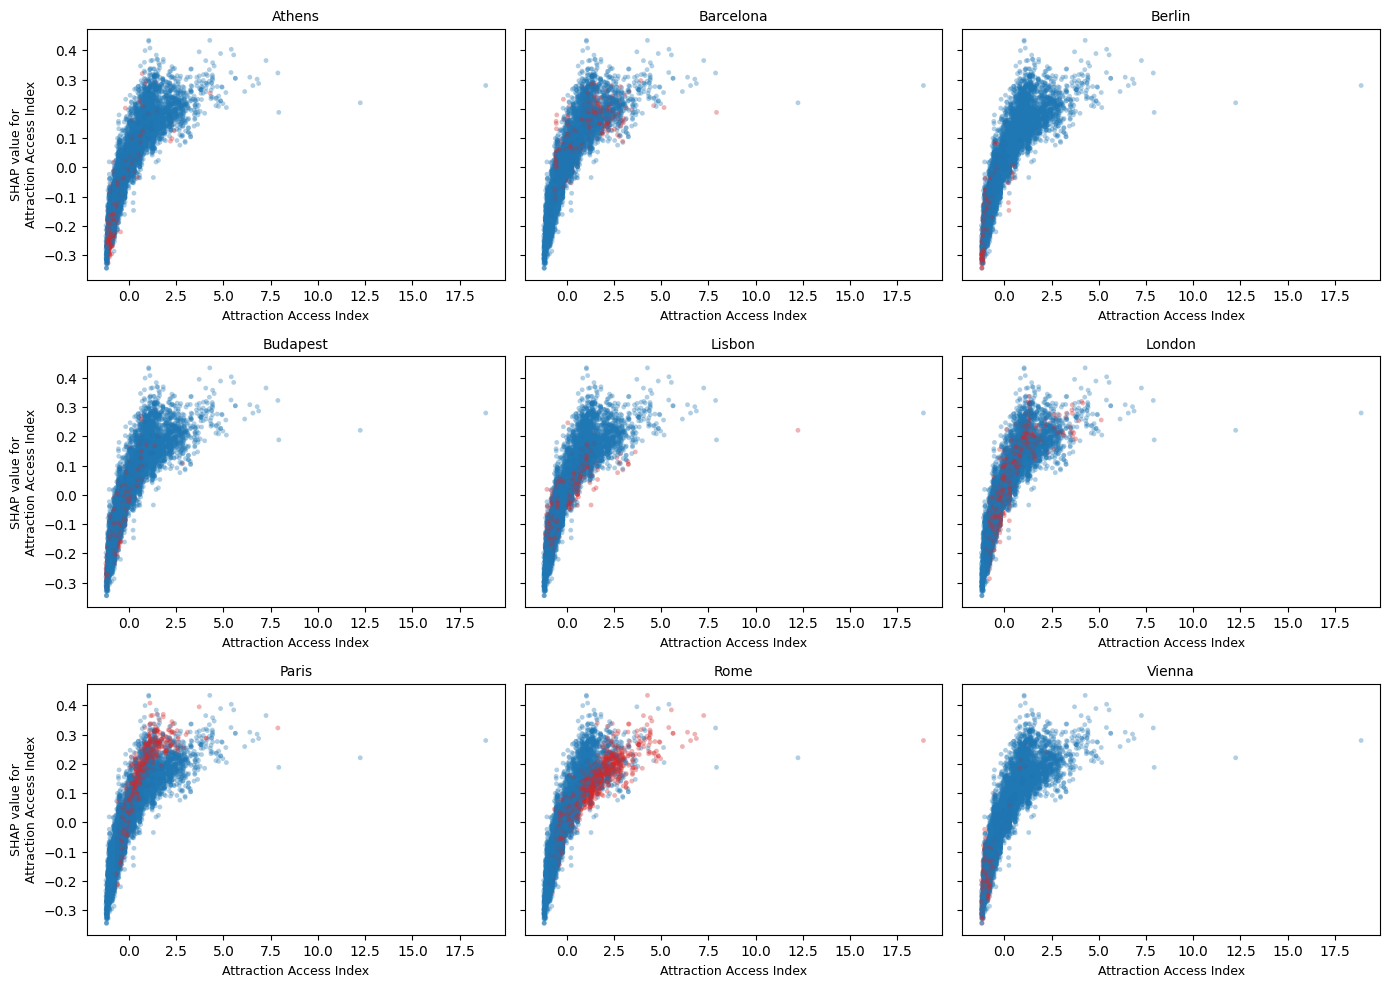

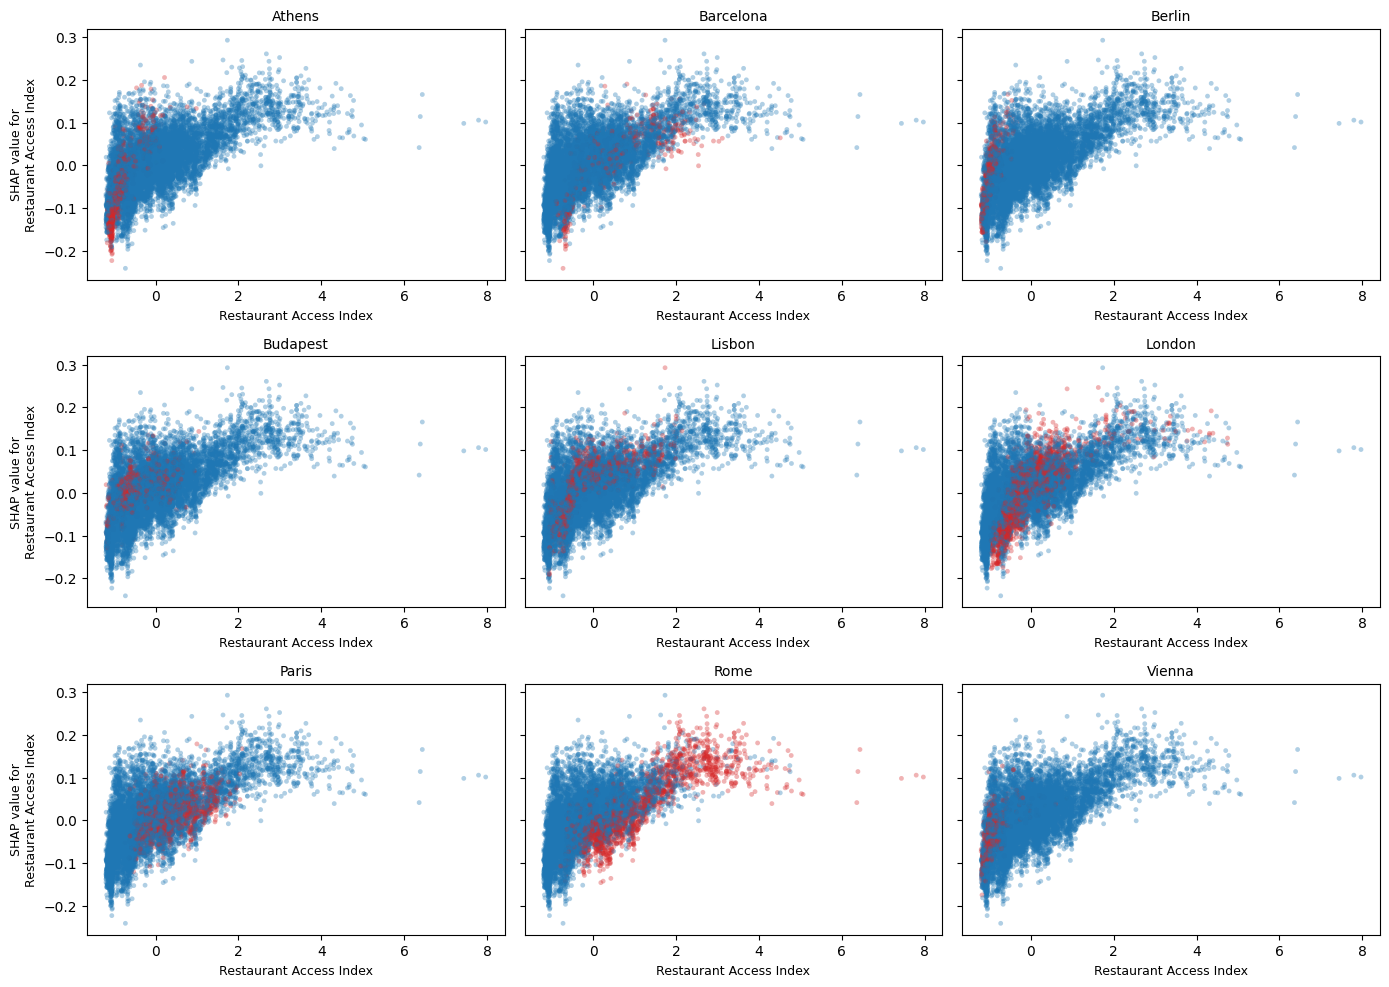

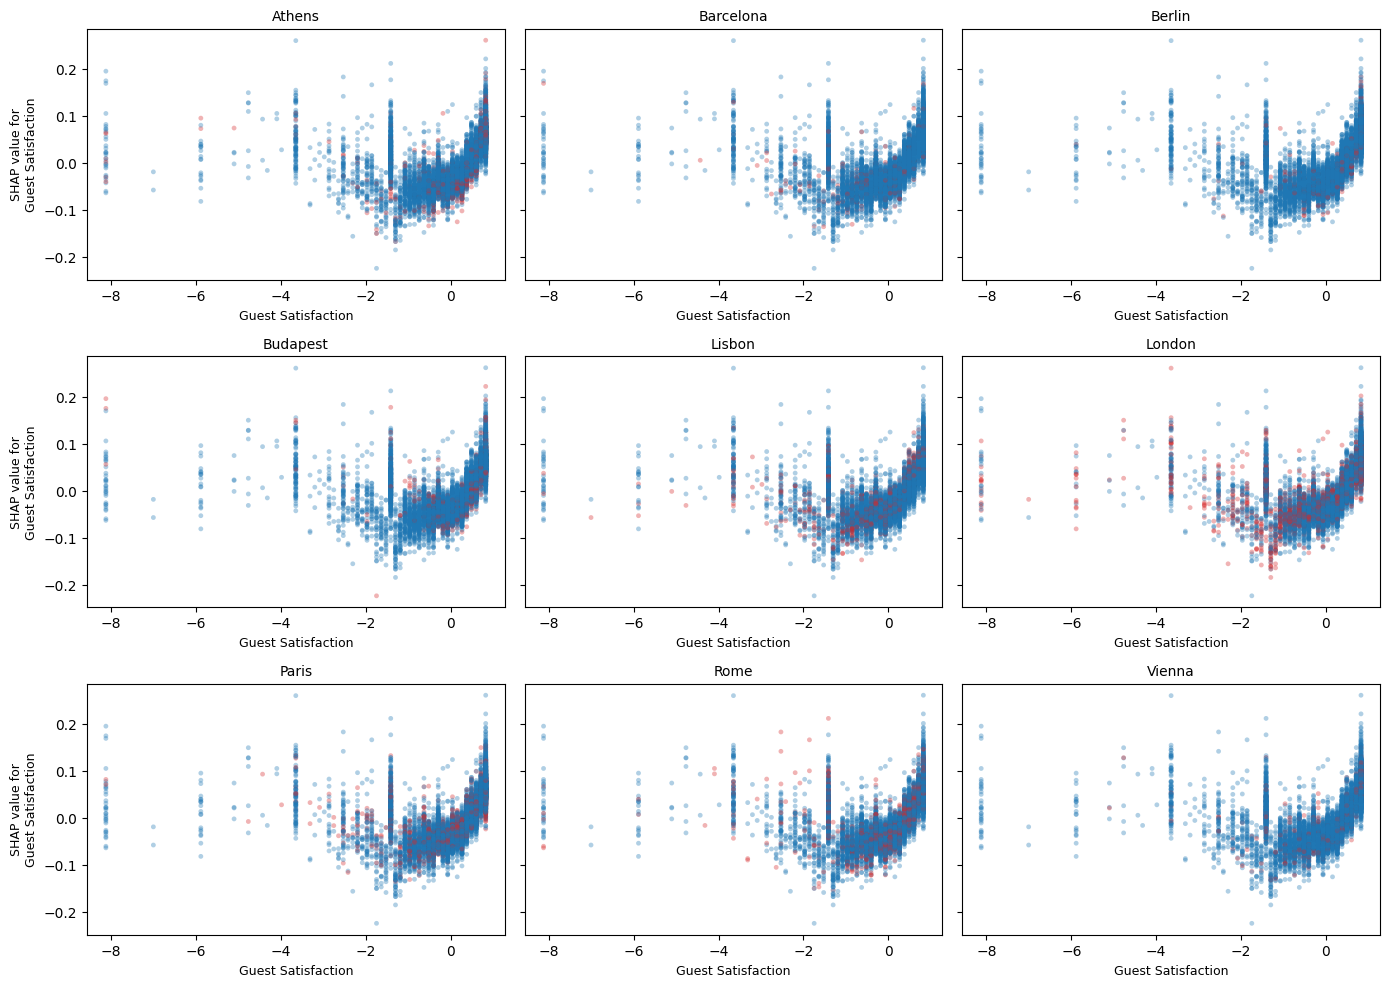

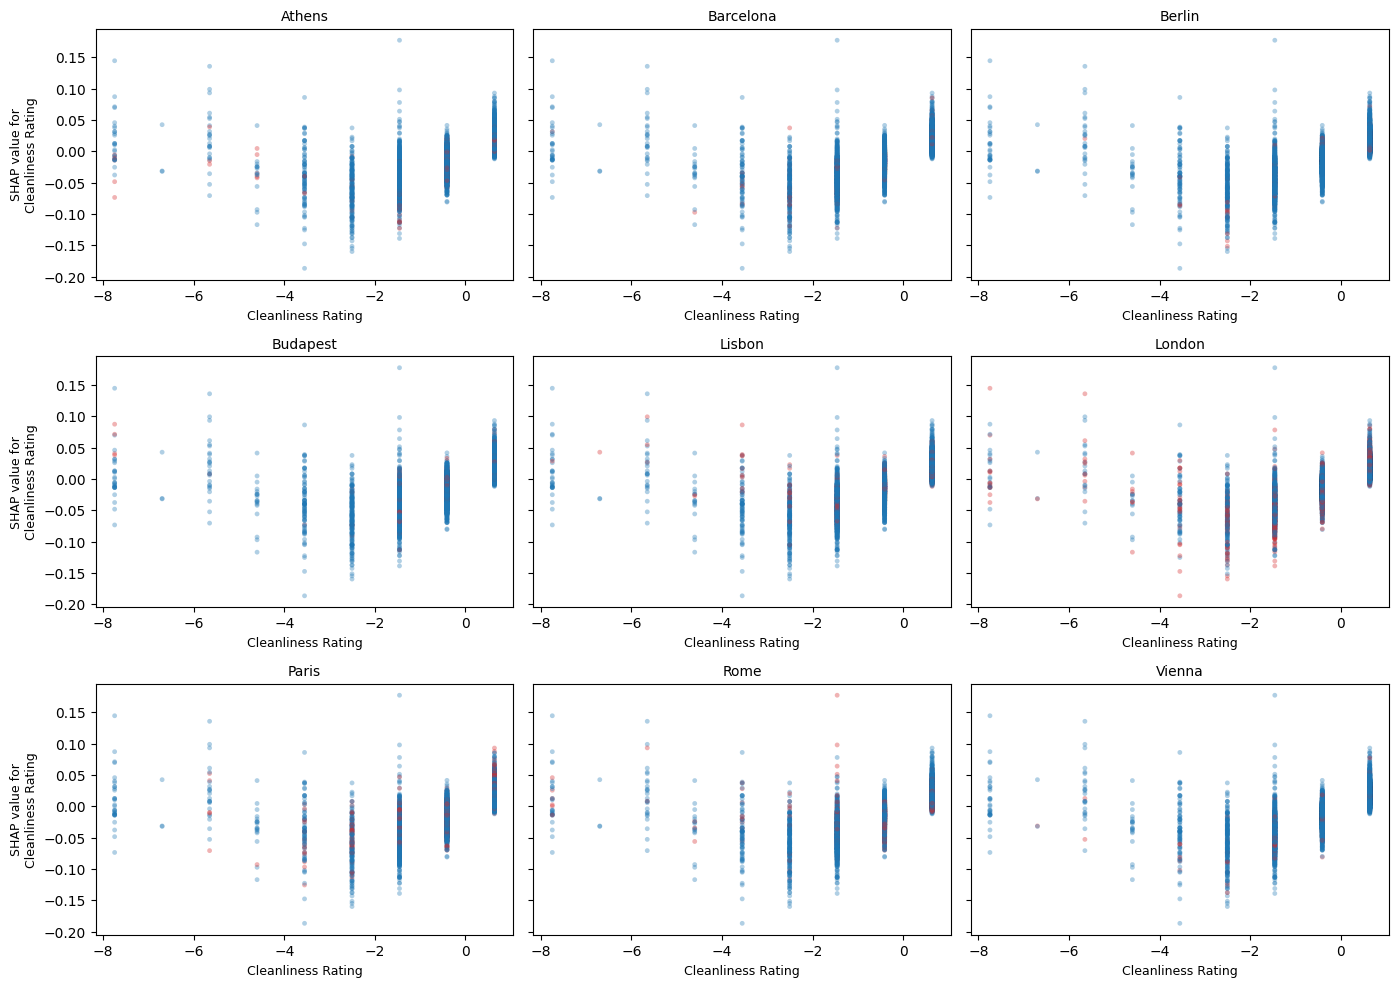

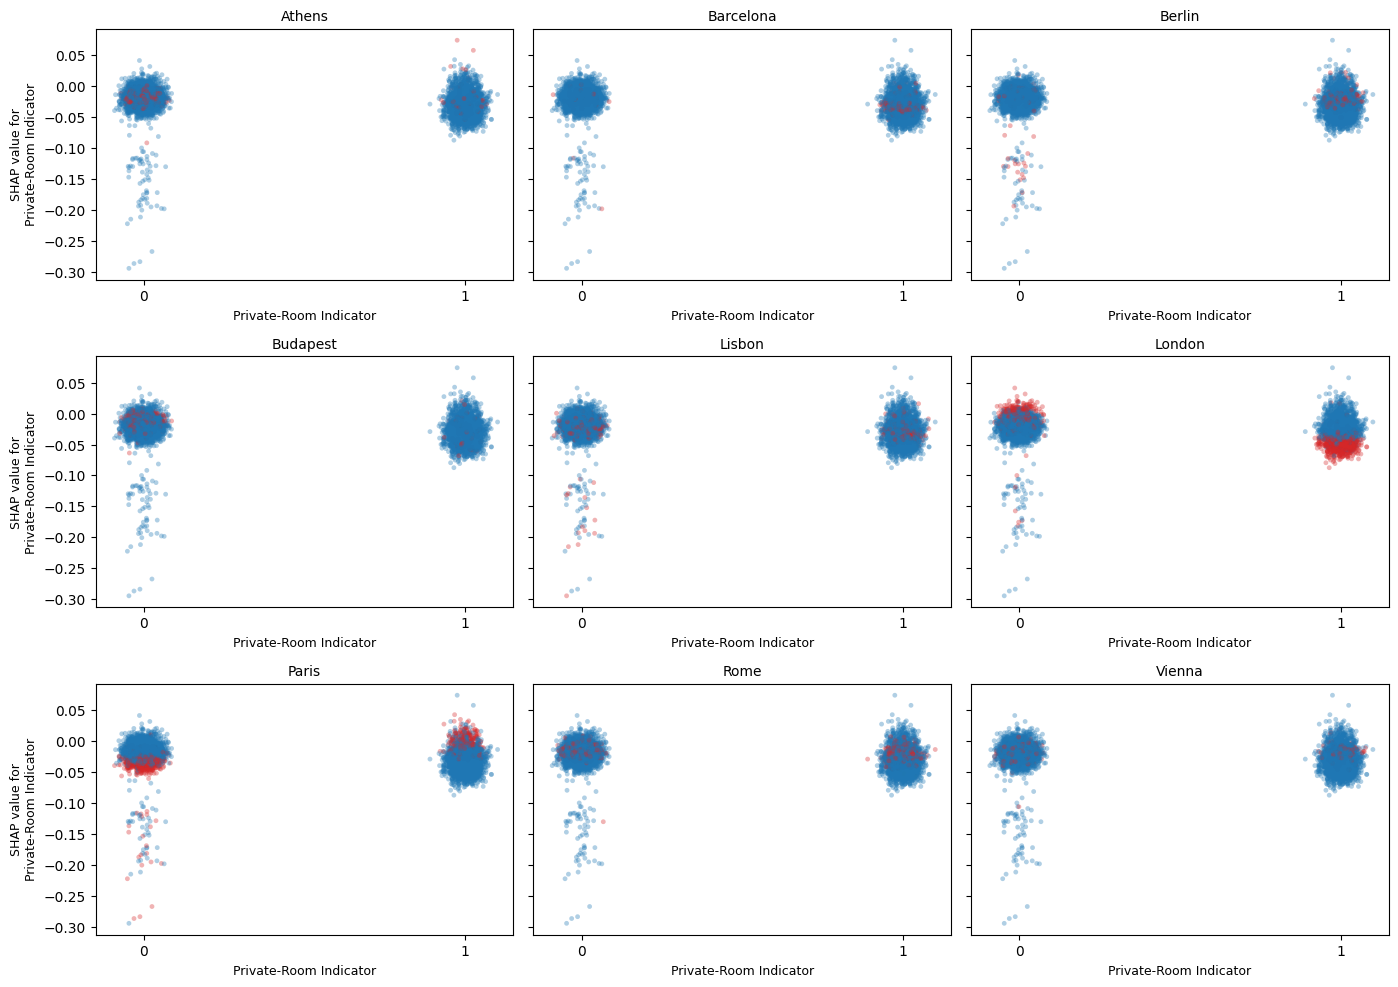

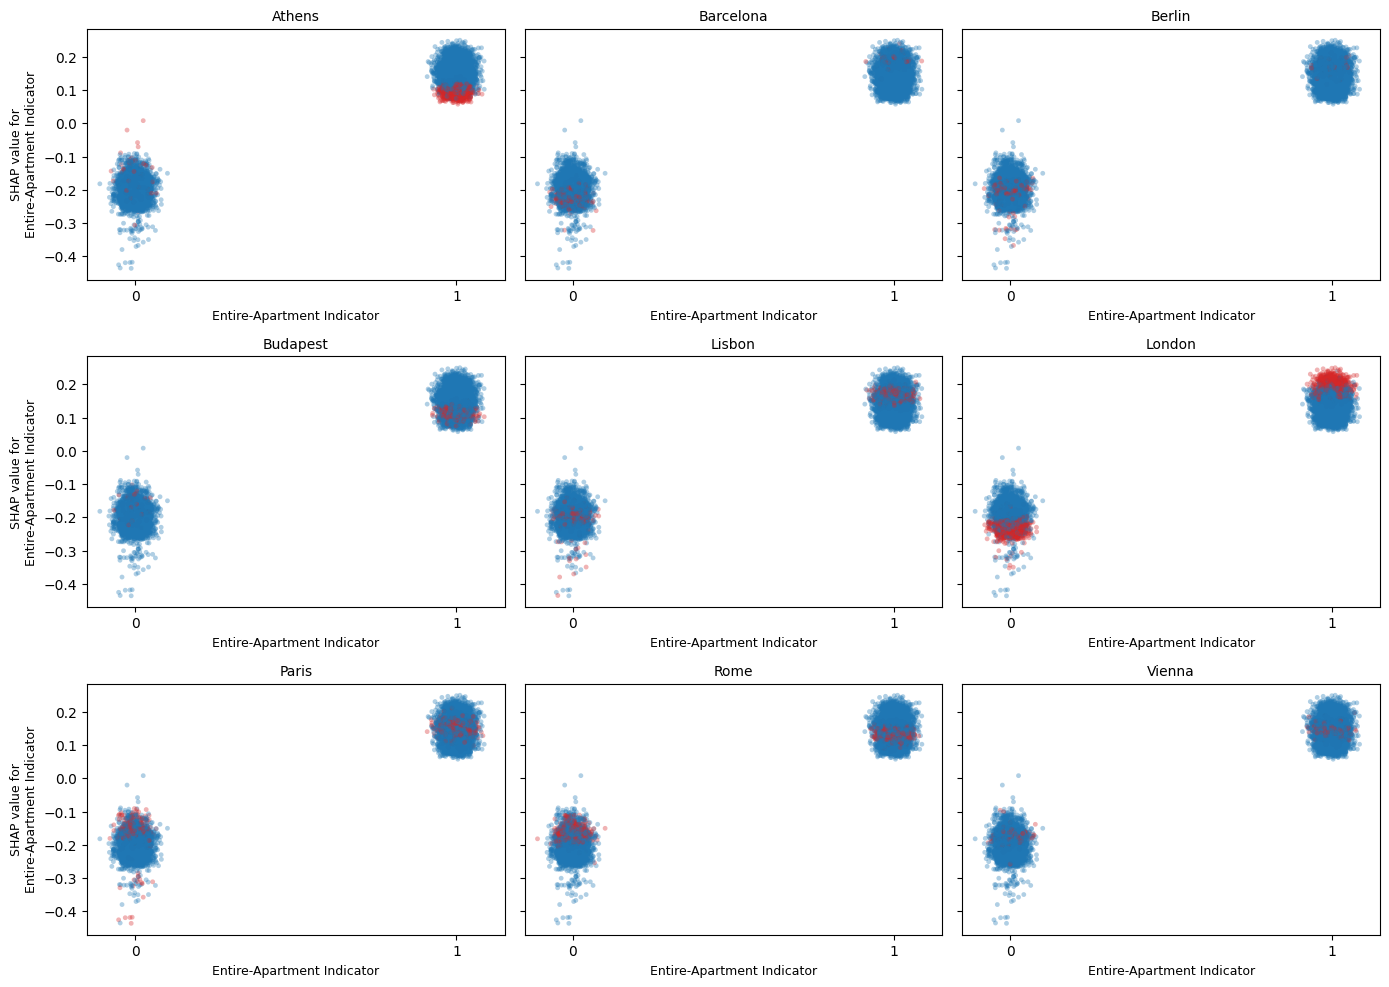

In [19]:
# Plot selected SHAP feature interactions with city fixed effects.
from matplotlib.lines import Line2D

city_interaction_features = [
    "attr_index",
    "rest_index",
    "satisfaction_rating",
    "cleanliness_rating",
    "room_type_private",
    "room_type_apt",
]

city_dummy_features = sorted([feature for feature in feature_names if feature.startswith("city_")])
expected_city_dummy_count = 9
if len(city_dummy_features) != expected_city_dummy_count:
    raise ValueError(
        f"Expected {expected_city_dummy_count} city dummy features, found {len(city_dummy_features)}."
    )

missing_features = sorted(set(city_interaction_features + city_dummy_features) - set(feature_names))
if missing_features:
    raise ValueError(f"Missing features for city-dummy SHAP interaction plots: {missing_features}")

city_interaction_title_map = {
    "attr_index": "Attraction Access Index",
    "rest_index": "Restaurant Access Index",
    "satisfaction_rating": "Guest Satisfaction",
    "cleanliness_rating": "Cleanliness Rating",
    "room_type_private": "Private-Room Indicator",
    "room_type_apt": "Entire-Apartment Indicator",
}

city_interaction_file_map = {
    "attr_index": "6_2_CityDummyInteractionsByAttractionAccess",
    "rest_index": "6_2_CityDummyInteractionsByRestaurantAccess",
    "satisfaction_rating": "6_2_CityDummyInteractionsByGuestSatisfaction",
    "cleanliness_rating": "6_2_CityDummyInteractionsByCleanliness",
    "room_type_private": "6_2_CityDummyInteractionsByPrivateRoom",
    "room_type_apt": "6_2_CityDummyInteractionsByEntireApartment",
}

X_test_df = pd.DataFrame(X_test, columns=feature_names)
tuned_shap_df = pd.DataFrame(tuned_shap_values, columns=feature_names)
binary_x_features = {"room_type_private", "room_type_apt"}
city_color_map = {0: "#1f77b4", 1: "#d62728"}
legend_handles = [
    Line2D([0], [0], marker="o", color="w", label="city dummy = 0", markerfacecolor=city_color_map[0], markersize=7),
    Line2D([0], [0], marker="o", color="w", label="city dummy = 1", markerfacecolor=city_color_map[1], markersize=7),
]

for base_feature in city_interaction_features:
    fig, axes = plt.subplots(3, 3, figsize=(14, 10.5), sharey=True)
    axes = axes.ravel()
    base_x = X_test_df[base_feature].to_numpy(dtype=float)
    shap_y = tuned_shap_df[base_feature].to_numpy(dtype=float)

    for ax, city_dummy in zip(axes, city_dummy_features):
        city_values = X_test_df[city_dummy].round().astype(int).to_numpy()
        plot_x = base_x.copy()
        if base_feature in binary_x_features:
            rng = np.random.default_rng(RANDOM_STATE)
            plot_x = plot_x + rng.normal(0, 0.025, size=len(plot_x))

        point_colors = np.where(city_values == 1, city_color_map[1], city_color_map[0])
        ax.scatter(plot_x, shap_y, c=point_colors, alpha=0.35, s=12, linewidths=0)
        ax.set_title(f"{city_dummy.replace('city_', '')}", fontsize=10)
        ax.set_xlabel(city_interaction_title_map[base_feature], fontsize=9)
        ax.grid(False)
        if base_feature in binary_x_features:
            ax.set_xticks([0, 1])
            ax.set_xlim(-0.15, 1.15)

    for row_start in [0, 3, 6]:
        axes[row_start].set_ylabel(f"SHAP value for\n{city_interaction_title_map[base_feature]}", fontsize=9)

    # fig.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=True, fontsize=9)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    city_interaction_path = Path("plots_overleaf") / f"{city_interaction_file_map[base_feature]}.png"
    plt.savefig(
        city_interaction_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)


## 5.20 Elastic Net Interaction Design
Select a compact interaction set for Elastic Net using evidence from SHAP dependence plots and PCA feature groups.

**Output.** Displays the interaction rationale and top tuned XGBoost features.


In [ ]:
# Record targeted interaction rationale.
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

selected_interaction_rationale = pd.DataFrame([
    {
        "left": "dist",
        "right": "attr_index",
    },
    {
        "left": "dist",
        "right": "rest_index",
    },
    {
        "left": "rest_index",
        "right": "attr_index",
    },
    {
        "left": "dist",
        "right": "metro_dist",
    },
    {
        "left": "cleanliness_rating",
        "right": "satisfaction_rating",
    },
    {
        "left": "is_superhost",
        "right": "satisfaction_rating",
    },
    {
        "left": "is_superhost",
        "right": "cleanliness_rating",
    },
    {
        "left": "city_Athens",
        "right": "rest_index",
    },
    {
        "left": "city_Barcelona",
        "right": "rest_index",
    },
    {
        "left": "city_Berlin",
        "right": "rest_index",
    },
    {
        "left": "city_Budapest",
        "right": "rest_index",
    },
    {
        "left": "city_Lisbon",
        "right": "rest_index",
    },
    {
        "left": "city_London",
        "right": "rest_index",
    },
    {
        "left": "city_Paris",
        "right": "rest_index",
    },
    {
        "left": "city_Rome",
        "right": "rest_index",
    },
    {
        "left": "city_Vienna",
        "right": "rest_index",
    },
    {
        "left": "city_Athens",
        "right": "attr_index",
    },
    {
        "left": "city_Barcelona",
        "right": "attr_index",
    },
    {
        "left": "city_Berlin",
        "right": "attr_index",
    },
    {
        "left": "city_Budapest",
        "right": "attr_index",
    },
    {
        "left": "city_Lisbon",
        "right": "attr_index",
    },
    {
        "left": "city_London",
        "right": "attr_index",
    },
    {
        "left": "city_Paris",
        "right": "attr_index",
    },
    {
        "left": "city_Rome",
        "right": "attr_index",
    },
    {
        "left": "city_Vienna",
        "right": "attr_index",
    },
    {
        "left": "city_London",
        "right": "room_type_private",
    },
    {
        "left": "city_Paris",
        "right": "room_type_private",
    },
    {
        "left": "city_Athens",
        "right": "room_type_apt",
    },
    {
        "left": "city_London",
        "right": "room_type_apt",
    }
])

interaction_pairs = list(
    selected_interaction_rationale[["left", "right"]].itertuples(index=False, name=None)
)


print(f"Selected interaction count: {len(interaction_pairs)}")
display(selected_interaction_rationale)


Selected interaction count: 29


,left,right
0,dist,attr_index
1,dist,rest_index
2,rest_index,attr_index
3,dist,metro_dist
4,cleanliness_rating,satisfaction_rating
5,is_superhost,satisfaction_rating
6,is_superhost,cleanliness_rating
7,city_Athens,rest_index
8,city_Barcelona,rest_index
9,city_Berlin,rest_index


## 5.21 Elastic Net Feature Builder
Define a transformer that reconstructs city fixed effects and appends only the selected pairwise interactions inside each training fold.

**Output.** Defines the reusable Elastic Net feature transformer.


In [38]:
# Build city fixed-effects and interaction features.
class AirbnbElasticNetFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_cols, binary_cols, categorical_col, interaction_pairs=None):
        self.numeric_cols = numeric_cols
        self.binary_cols = binary_cols
        self.categorical_col = categorical_col
        self.interaction_pairs = interaction_pairs

    def fit(self, X, y=None):
        self.numeric_cols_ = list(self.numeric_cols)
        self.binary_cols_ = list(self.binary_cols)
        self.interaction_pairs_ = list(self.interaction_pairs or [])

        self.numeric_scaler_ = StandardScaler()
        self.numeric_scaler_.fit(X[self.numeric_cols_])

        self.city_encoder_ = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
        self.city_encoder_.fit(X[[self.categorical_col]])
        self.city_cols_ = list(self.city_encoder_.get_feature_names_out([self.categorical_col]))
        return self

    def transform(self, X):
        X = X.copy()
        numeric_scaled = pd.DataFrame(
            self.numeric_scaler_.transform(X[self.numeric_cols_]),
            columns=self.numeric_cols_,
            index=X.index,
        )
        binary = X[self.binary_cols_].astype(float)
        city = pd.DataFrame(
            self.city_encoder_.transform(X[[self.categorical_col]]),
            columns=self.city_cols_,
            index=X.index,
        )

        out = pd.concat([numeric_scaled, binary, city], axis=1)

        for left, right in self.interaction_pairs_:
            out[f"{left}_x_{right}"] = out[left] * out[right]

        self.feature_names_out_ = list(out.columns)
        return out.to_numpy()

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)


## 5.22 Elastic Net Tuning and Evaluation
Tune `alpha` and `l1_ratio` for the targeted-interaction Elastic Net and compare it with the city fixed-effects OLS baseline and tuned XGBoost.

**Output.** Displays best hyperparameters, feature counts, model metrics, and top coefficients.


In [39]:
# Tune and evaluate targeted Elastic Net.
X_raw = df[raw_feature_cols].copy()
y_raw = df[target_col].copy()

X_train_raw_enet, X_test_raw_enet, y_train_enet, y_test_enet = train_test_split(
    X_raw,
    y_raw,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["city"],
)

enet_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
enet_cv_splits = list(enet_cv.split(X_train_raw_enet, X_train_raw_enet["city"]))

baseline_city_fe_pipe = Pipeline([
    ("features", AirbnbElasticNetFeatures(
        numeric_cols=numeric_cols,
        binary_cols=binary_cols,
        categorical_col="city",
    )),
    ("scale", StandardScaler()),
    ("model", LinearRegression()),
])

elastic_net_pipe = Pipeline([
    ("features", AirbnbElasticNetFeatures(
        numeric_cols=numeric_cols,
        binary_cols=binary_cols,
        categorical_col="city",
        interaction_pairs=interaction_pairs,
    )),
    ("scale", StandardScaler()),
    ("model", ElasticNet(max_iter=30000, random_state=RANDOM_STATE)),
])

enet_param_grid = {
    "model__alpha": np.logspace(-4, -0.25, 16),
    "model__l1_ratio": [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95],
}

baseline_cv_scores = cross_val_score(
    baseline_city_fe_pipe,
    X_train_raw_enet,
    y_train_enet,
    cv=enet_cv_splits,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
baseline_cv_rmse = float(-baseline_cv_scores.mean())
baseline_city_fe_pipe.fit(X_train_raw_enet, y_train_enet)
baseline_test_pred = baseline_city_fe_pipe.predict(X_test_raw_enet)
baseline_test_rmse = float(root_mean_squared_error(y_test_enet, baseline_test_pred))
baseline_test_r2 = float(r2_score(y_test_enet, baseline_test_pred))

enet_search = GridSearchCV(
    elastic_net_pipe,
    param_grid=enet_param_grid,
    cv=enet_cv_splits,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
)
enet_search.fit(X_train_raw_enet, y_train_enet)

best_enet = enet_search.best_estimator_
enet_test_pred = best_enet.predict(X_test_raw_enet)
enet_cv_rmse = float(-enet_search.best_score_)
enet_test_rmse = float(root_mean_squared_error(y_test_enet, enet_test_pred))
enet_test_r2 = float(r2_score(y_test_enet, enet_test_pred))

enet_feature_names = best_enet.named_steps["features"].get_feature_names_out()
enet_coef_df = (
    pd.DataFrame({
        "feature": enet_feature_names,
        "coef": best_enet.named_steps["model"].coef_,
    })
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)

elastic_net_summary = pd.DataFrame({
    "Model": ["City FE OLS baseline", "XGBoost tuned", "Elastic Net FE + targeted interactions"],
    "CV-RMSE": [baseline_cv_rmse, study.best_value, enet_cv_rmse],
    "Test RMSE": [baseline_test_rmse, rmse_tuned, enet_test_rmse],
    "Test R²": [baseline_test_r2, r2_tuned, enet_test_r2],
}).set_index("Model")


print("Best Elastic Net hyperparameters:")
display(pd.DataFrame([enet_search.best_params_]).rename(columns={
    "model__alpha": "alpha",
    "model__l1_ratio": "l1_ratio",
}))

display(elastic_net_summary.round(4))


Best Elastic Net hyperparameters:


,alpha,l1_ratio
0,0.000316,0.95


,CV-RMSE,Test RMSE,Test R²
Model,,,
City FE OLS baseline,0.3227,0.3265,0.6631
XGBoost tuned,0.2245,0.2015,0.8717
Elastic Net FE + targeted interactions,0.3094,0.3118,0.6927


In [40]:
nonzero_coef_count = int((enet_coef_df["coef"] != 0).sum())
print(f"Non-zero Elastic Net coefficients: {nonzero_coef_count} out of {len(enet_coef_df)}")
display(enet_coef_df.round(4))

Non-zero Elastic Net coefficients: 47 out of 52


,feature,coef,abs_coef
0,city_Rome,-0.4574,0.4574
1,room_type_apt,0.3725,0.3725
2,city_Budapest,-0.3460,0.3460
3,city_Athens,-0.3316,0.3316
4,city_Lisbon,-0.2881,0.2881
5,room_type_private,0.1972,0.1972
6,city_Paris,-0.1889,0.1889
7,city_Vienna,-0.1809,0.1809
8,city_Barcelona,-0.1476,0.1476
9,city_London,-0.1344,0.1344


## 5.23 Elastic Net Coefficient Plot
Visualize the largest standardized coefficients selected by the targeted Elastic Net model.

**Output.** Saves the Elastic Net coefficient plot.


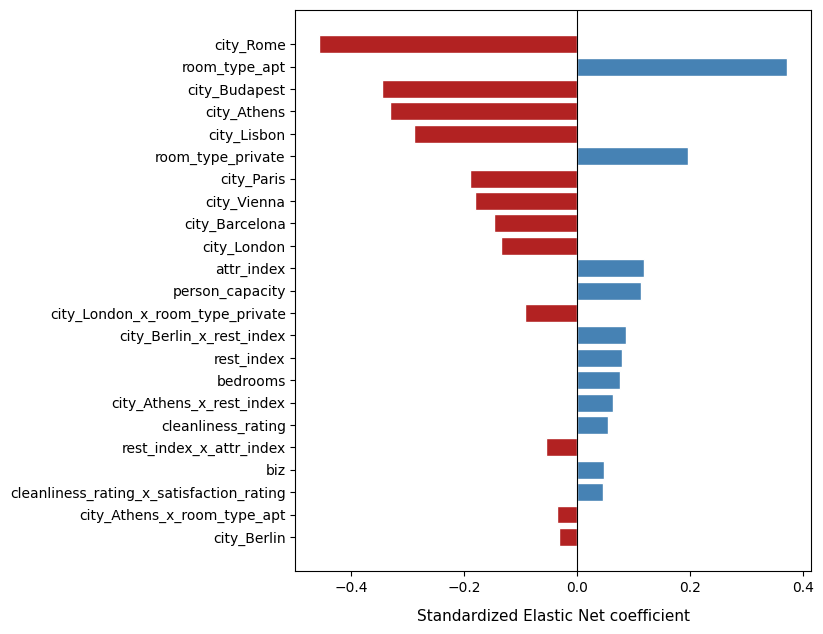

In [41]:
# Plot largest Elastic Net coefficients.
nonzero_enet_coefs = enet_coef_df.head(23).sort_values("abs_coef", ascending=True)

fig, ax = plt.subplots(figsize=(9.2, 7.2))
coef_colors = np.where(nonzero_enet_coefs["coef"] >= 0, "steelblue", "firebrick")
ax.barh(nonzero_enet_coefs["feature"], nonzero_enet_coefs["coef"], color=coef_colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized Elastic Net coefficient", fontsize=11, labelpad=10)
fig.subplots_adjust(left=0.42, right=0.98, bottom=0.12, top=0.90)
plt.savefig("plots_overleaf/6_3_ElasticNetTopCoefficients.png", dpi=300, bbox_inches="tight", pad_inches=0.12)
plt.show()


## 5.24 Advanced Model Comparison Plot
Summarize CV-RMSE, test RMSE, and test-set R² across the advanced-model candidates.

**Output.** Saves the Section 5 advanced model-comparison plot.


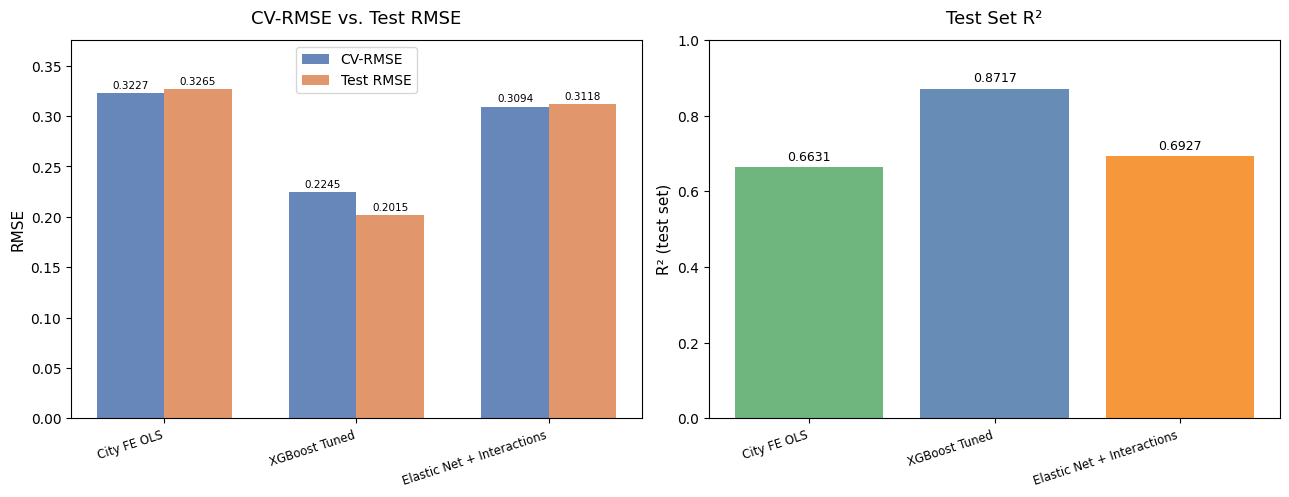

In [42]:
# Plot advanced model comparison.
model_labels = list(elastic_net_summary.index)
display_label_map = {
    "City FE OLS baseline": "City FE OLS",
    "XGBoost tuned": "XGBoost Tuned",
    "Elastic Net FE + targeted interactions": "Elastic Net + Interactions",
}
plot_labels = [display_label_map[label] for label in model_labels]
x = np.arange(len(model_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

ax = axes[0]
bars_cv = ax.bar(
    x - width / 2,
    elastic_net_summary["CV-RMSE"],
    width,
    label="CV-RMSE",
    color="#4c72b0",
    alpha=0.85,
)
bars_test = ax.bar(
    x + width / 2,
    elastic_net_summary["Test RMSE"],
    width,
    label="Test RMSE",
    color="#dd8452",
    alpha=0.85,
)
ax.set_title("CV-RMSE vs. Test RMSE", fontsize=13, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_labels, rotation=18, ha="right", fontsize=8.5)
ax.set_ylabel("RMSE", fontsize=11)
ax.legend(loc="upper center", fontsize=10)
ax.set_ylim(0, elastic_net_summary[["CV-RMSE", "Test RMSE"]].values.max() * 1.15)
for bar in [*bars_cv, *bars_test]:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=7.5,
    )

ax2 = axes[1]
r2_color_map = {
    "City FE OLS": "#55a868",
    "XGBoost Tuned": "#4c78a8",
    "Elastic Net + Interactions": "#f58518",
}
r2_colors = [r2_color_map[label] for label in plot_labels]
bars_r2 = ax2.bar(x, elastic_net_summary["Test R²"], color=r2_colors, alpha=0.85)
ax2.set_title("Test Set R²", fontsize=13, pad=12)
ax2.set_xticks(x)
ax2.set_xticklabels(plot_labels, rotation=18, ha="right", fontsize=8.5)
ax2.set_ylabel("R² (test set)", fontsize=11)
ax2.set_ylim(0, 1.0)
for bar in bars_r2:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("plots_overleaf/7_0_AdvancedModelComparison.png", dpi=300, bbox_inches="tight")
plt.show()
